# Lab 4-4: 지도학습 도전과제 극복을 위한 핵심 테크닉 실습

본 실습에서는 Lab 4-3에서 체감한 머신러닝/딥러닝의 **도전과제(Challenging Problems)**를 극복하기 위한 대표적인 해결 기법들을 직접 구현하고 검증합니다.

---

### [학습 목표]
1. **기울기 소실 극복 (Residual Connection)**: 커스텀 `ResidualBlock` 레이어를 구현하고, 깊은 Plain 망과 ResNet 구조의 학습 성능 차이를 비교합니다.
2. **과적합 극복 (L1 / L2 가중치 규제)**: 모델 가중치에 패널티를 부여하는 L1, L2, ElasticNet(L1+L2) 정규화를 적용하여 검증 손실(Val Loss) 안정화를 확인합니다.
3. **과적합 극복 (Dropout & Early Stopping)**: 학습 중 무작위로 뉴런을 비활성화하는 `Dropout`을 적용하고 과적합 억제 효과를 관찰합니다.
4. **클래스 불균형 극복 (Class Weighting & Data Augmentation)**: 소수 클래스에 가중치를 부여하는 `class_weight`와 소수 클래스만을 증강하는 `Balanced Data Augmentation`을 적용하여 소수 클래스 검출 성능(Recall/F1-Score)을 개선합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow 버전:", tf.__version__)


I0000 00:00:1790074836.083622   17703 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790074836.127863   17703 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790074837.752574   17703 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 버전: 2.21.0


---
## Part 1. Residual Connection을 통한 Vanishing Gradient 완화 실습

깊은 신경망에서 층을 깊게 쌓을수록 기울기 소실(Vanishing Gradient)이나 성능 저하(Degradation)가 발생합니다.
ResNet의 핵심 아이디어인 **Residual Connection (ResNet)** 은 입력 $x$를 변형 없이 그대로 출력에 더해주는 $F(x) + x$ 지름길(Shortcut)을 제공함으로써 기울기가 손실 없이 초기 층까지 역전파되도록 돕습니다.

- Plain Deep Network (Residual 없음)
- Residual Network (Residual Block 포함)

두 모델을 동일한 데이터셋에서 학습시켜 성능을 비교합니다.


In [2]:
# 1. 데이터 준비
X_res, y_res = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

scaler_res = StandardScaler()
X_train_res = scaler_res.fit_transform(X_train_res)
X_test_res = scaler_res.transform(X_test_res)

print(f"학습 샘플 수: {len(X_train_res)}, 검증 샘플 수: {len(X_test_res)}")


학습 샘플 수: 1400, 검증 샘플 수: 600


### 1-1. Plain Deep Network 정의 (Residual 없음)


In [3]:
def build_deep_plain(layers=20, units=64):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-2. Residual Block 정의 및 Residual Network 정의


In [4]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(units, activation="relu")
        self.dense2 = tf.keras.layers.Dense(units, activation=None)
        self.activation = tf.keras.layers.Activation("relu")

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        # ✅ Residual(Skip) Connection: H(x) = ReLU(F(x) + x)
        return self.activation(x + inputs)

def build_residual_network(blocks=10, units=64):
    inputs = tf.keras.Input(shape=(2,))
    x = tf.keras.layers.Dense(units, activation="relu")(inputs)
    for _ in range(blocks):
        # ✅ Residual Block을 x에 순차 적용 (블록 10개 = Dense 20층 + skip)
        x = ResidualBlock(units)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-3. 모델 학습 (Plain vs Residual) 및 결과 비교 시각화


W0000 00:00:1790074856.517309   17703 graph_view.cc:850] No registered '' OpKernel for CPU devices compatible with node {{node StatefulPartitionedCall/functional_21_1/residual_block_9_1/activation_9_1/Relu}}
	.  Registered:  <no registered kernels>

W0000 00:00:1790074856.518566   17703 graph_view.cc:850] No registered '' OpKernel for CPU devices compatible with node {{node StatefulPartitionedCall/functional_21_1/residual_block_8_1/activation_8_1/Relu}}
	.  Registered:  <no registered kernels>

W0000 00:00:1790074856.519171   17703 graph_view.cc:850] No registered '' OpKernel for CPU devices compatible with node {{node StatefulPartitionedCall/functional_21_1/residual_block_7_1/activation_7_1/Relu}}
	.  Registered:  <no registered kernels>

W0000 00:00:1790074856.520067   17703 graph_view.cc:850] No registered '' OpKernel for CPU devices compatible with node {{node StatefulPartitionedCall/functional_21_1/residual_block_6_1/activation_6_1/Relu}}
	.  Registered:  <no registered kernels>



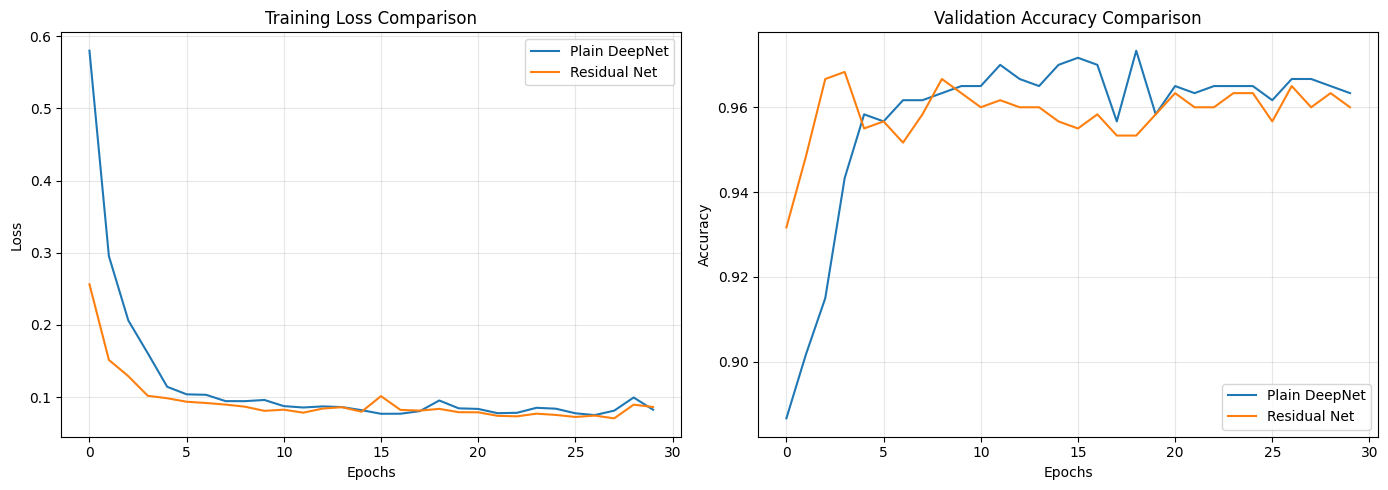

In [5]:
plain_model = build_deep_plain(layers=20, units=64)
history_plain = plain_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                                epochs=30, batch_size=32, verbose=0)

res_model = build_residual_network(blocks=10, units=64)
history_res = res_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                            epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_plain.history["loss"], label="Plain DeepNet")
plt.plot(history_res.history["loss"], label="Residual Net")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_plain.history["val_accuracy"], label="Plain DeepNet")
plt.plot(history_res.history["val_accuracy"], label="Residual Net")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Part 2. L1, L2 Regularization 실습

이번 파트에서는 **L1, L2 Regularization** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Regularization 유무 비교 (No Regularization, L1, L2, L1+L2)
- Validation Loss/Accuracy 곡선으로 비교


In [6]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
X_reg, y_reg = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)


### 2-1. 모델 생성 함수 (Regularization 적용 가능)


In [7]:
def build_model(regularizer=None):
    # ✅ 모든 Dense 레이어에 kernel_regularizer 적용 (None이면 규제 없음)
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizer)
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. Regularization 설정 및 모델 학습


In [8]:
models = {
    "No Regularization": build_model(),
    "L1 (0.001)": build_model(tf.keras.regularizers.l1(0.001)),
    "L2 (0.001)": build_model(tf.keras.regularizers.l2(0.001)),
    "L1+L2 (0.001)": build_model(tf.keras.regularizers.l1_l2(l1=0.001, l2=0.001))
}

histories = {}

for name, model in models.items():
    print(f"Training: {name}")
    history = model.fit(
        X_train_reg, y_train_reg,
        validation_data=(X_test_reg, y_test_reg),
        epochs=200,
        batch_size=16,
        verbose=0
    )
    histories[name] = history


Training: No Regularization


Training: L1 (0.001)


Training: L2 (0.001)


Training: L1+L2 (0.001)


### 2-3. 결과 시각화 (Loss & Accuracy)


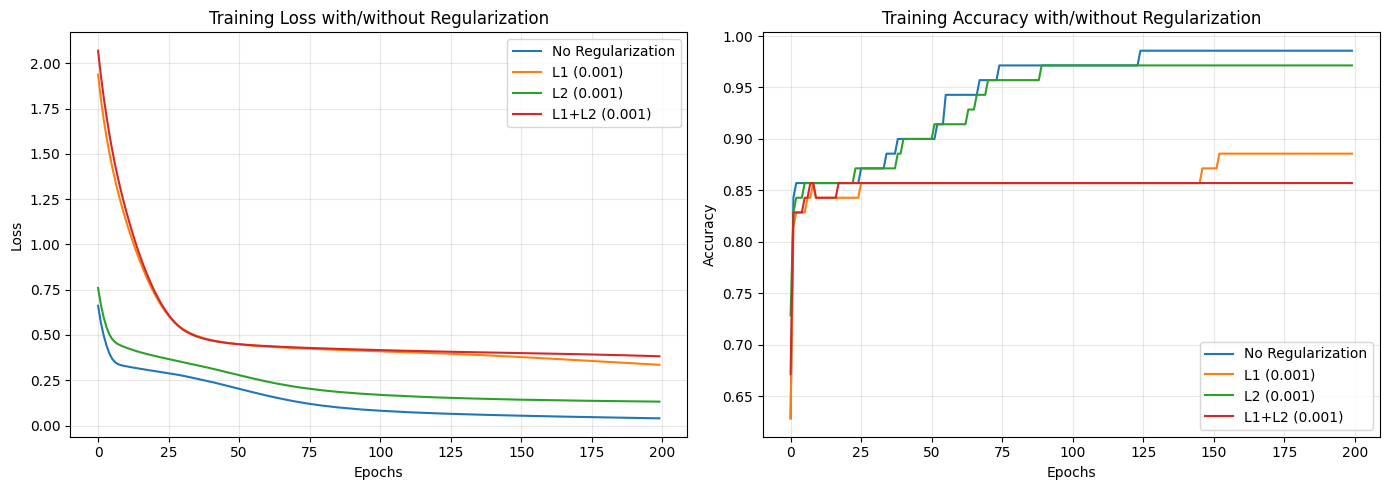

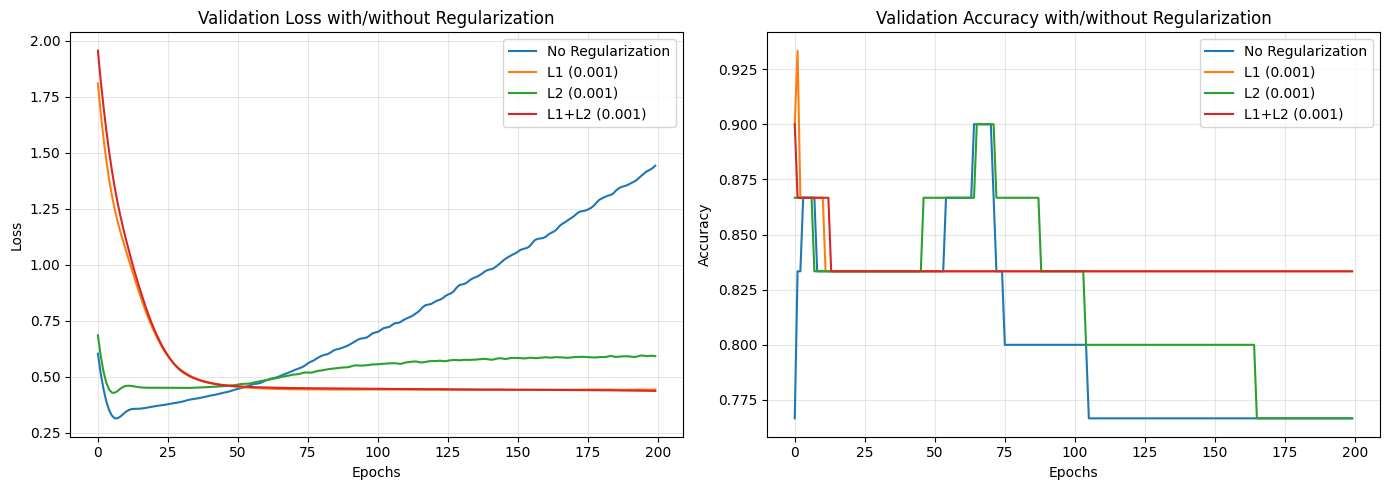

In [9]:
# 1. Training Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name}")
plt.title("Training Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name}")
plt.title("Training Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=f"{name}")
plt.title("Validation Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=f"{name}")
plt.title("Validation Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 3. Dropout 실습

이번 파트에서는 **Dropout** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Dropout 유무 비교
- Validation Loss/Accuracy 곡선으로 비교


In [10]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
# (Part 2와 동일한 100개 make_moons 데이터 사용)
print(f"X_train shape: {X_train_reg.shape}, X_test shape: {X_test_reg.shape}")


X_train shape: (70, 2), X_test shape: (30, 2)


### 3-1. Dropout 없는 모델과 Dropout 적용 모델 정의


In [11]:
def build_model_with_dropout():
    # ✅ Dense 레이어 사이에 Dropout(0.5) 삽입 (학습 시에만 뉴런 50% 무작위 비활성화)
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_model_without_dropout():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 3-2. 모델 학습 (Dropout 유무 비교) 및 결과 시각화


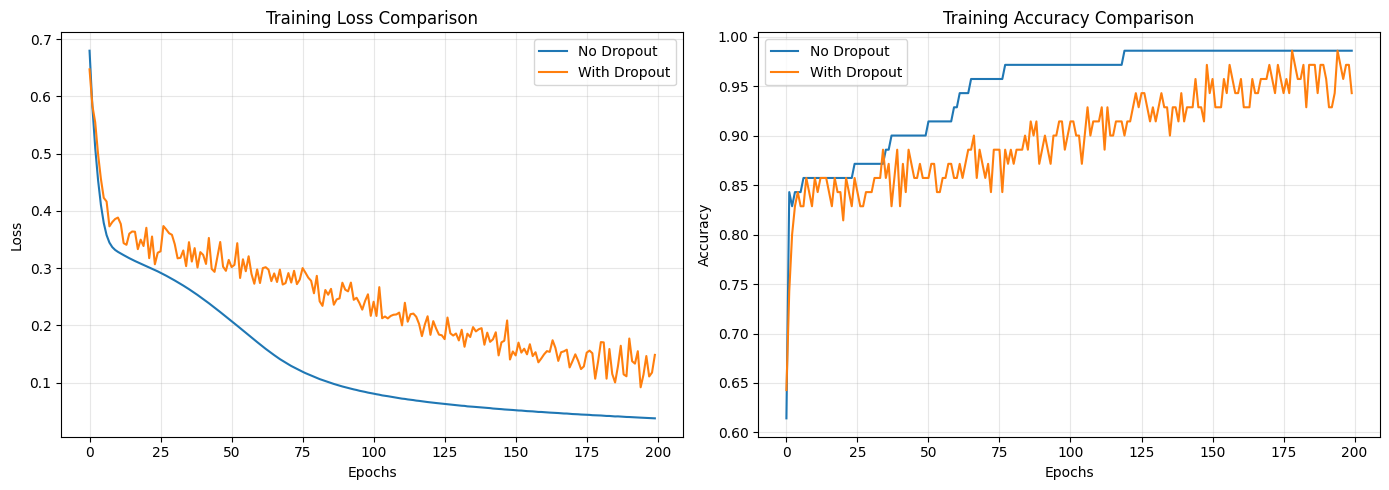

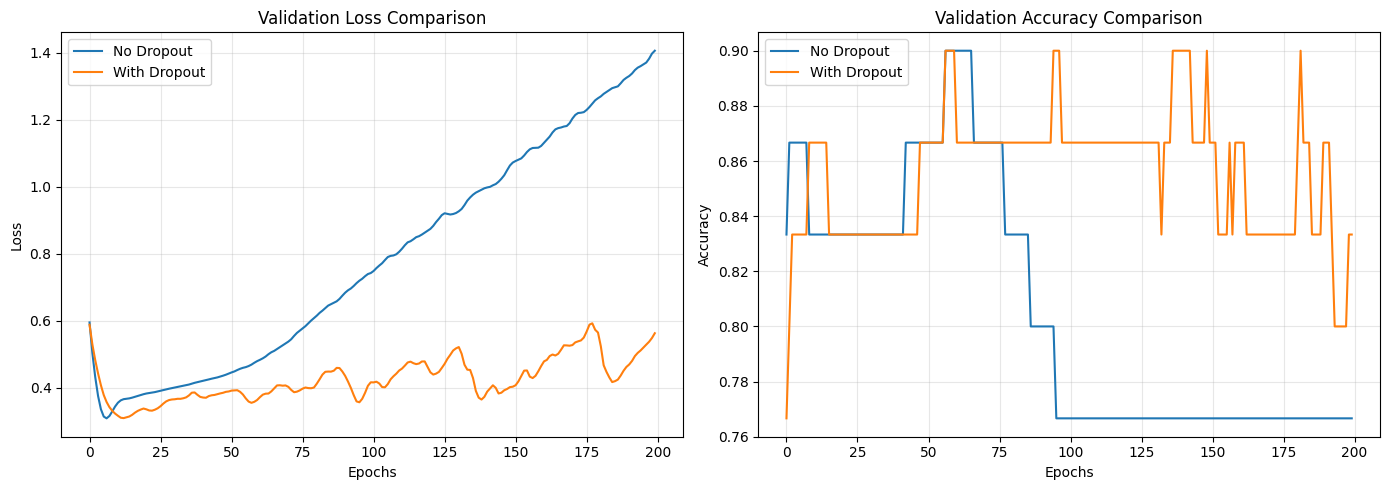

In [12]:
model_no_dropout = build_model_without_dropout()
model_with_dropout = build_model_with_dropout()

history_no_dropout = model_no_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

history_with_dropout = model_with_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

# 1. Training Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["loss"], label="No Dropout")
plt.plot(history_with_dropout.history["loss"], label="With Dropout")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["accuracy"], label="With Dropout")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["val_loss"], label="No Dropout")
plt.plot(history_with_dropout.history["val_loss"], label="With Dropout")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["val_accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["val_accuracy"], label="With Dropout")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 4. Balanced Data Augmentation & Class Weighting 실습

이번 실습에서는 **Class Imbalance 문제**를 다루는 두 가지 방법을 비교합니다.

- Baseline (불균형 데이터 그대로 학습)
- Balanced Data Augmentation (소수 클래스만 증강)
- Class Weighting (소수 클래스에 가중치 부여)

CIFAR-10 (Cat vs Dog) 데이터셋으로 실험합니다.


### 4-1. 데이터 준비 (CIFAR-10: Cat vs Dog, 불균형 만들기)


In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()

# 클래스 3=Cat, 5=Dog
mask_train = (y_train == 3) | (y_train == 5)  # 3=Cat, 5=Dog
mask_test = (y_test == 3) | (y_test == 5)
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test, y_test = X_test[mask_test], y_test[mask_test]

# 라벨 재정의: Cat=0, Dog=1
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

# Cat 샘플 줄여서 불균형 만들기
# cat data를 20%만 사용
cat_idx = np.where(y_train == 0)[0]
dog_idx = np.where(y_train == 1)[0]
np.random.seed(42)
cat_idx_reduced = np.random.choice(cat_idx, size=len(cat_idx)//5, replace=False)
imbalanced_idx = np.concatenate([cat_idx_reduced, dog_idx])
X_train, y_train = X_train[imbalanced_idx], y_train[imbalanced_idx]

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

print("Train class distribution (imbalanced):", np.bincount(y_train))


/usr/local/lib/python3.11/dist-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


Train class distribution (imbalanced): [1000 5000]


### 4-2. CNN 모델 정의


In [14]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(32,32,3)),
        tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 4-3. Balanced Data Augmentation (소수 클래스만 증강)


In [15]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

cat_imgs = X_train[y_train==0]
dog_imgs = X_train[y_train==1]
cat_labels = y_train[y_train==0]
dog_labels = y_train[y_train==1]

# ✅ 다수 클래스(Dog) - 소수 클래스(Cat) = 증강으로 채워야 할 샘플 수
needed = len(dog_labels) - len(cat_labels)
print("부족한 소수 클래스(Cat) 샘플 수:", needed)
augmented_cats, augmented_labels = [], []

# 소수 클래스(Cat)만 증강
for X_batch, y_batch in datagen.flow(cat_imgs, cat_labels, batch_size=32, seed=42):
    augmented_cats.append(X_batch)
    augmented_labels.append(y_batch)
    if len(np.concatenate(augmented_labels)) >= needed:
        break

augmented_cats = np.concatenate(augmented_cats)[:needed]
augmented_labels = np.concatenate(augmented_labels)[:needed]

# ✅ 원본 학습셋 + 증강된 Cat 샘플을 concat -> 5000:5000 균형 달성
X_balanced = np.concatenate([X_train, augmented_cats])
y_balanced = np.concatenate([y_train, augmented_labels])

print("Balanced train class distribution:", np.bincount(y_balanced))


부족한 소수 클래스(Cat) 샘플 수: 4000


Balanced train class distribution: [5000 5000]


### 4-4. Class Weighting 설정


In [16]:
# ✅ n_samples / (n_classes * n_samples_per_class) -> 소수 클래스에 큰 가중치
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(3.0), 1: np.float64(0.6)}


### 4-5. 학습 (Baseline vs Balanced Augmentation vs Class Weighting)


In [17]:
histories_cifar = {}

# 1. Baseline
print("1. Baseline 학습 중...")
model_base = build_model()
histories_cifar["Baseline"] = model_base.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 2. Balanced Data Augmentation
print("2. Balanced Data Augmentation 학습 중...")
model_aug = build_model()
histories_cifar["Balanced Augmentation"] = model_aug.fit(
    X_balanced, y_balanced, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 3. Class Weighting
print("3. Class Weighting 학습 중...")
model_weighted = build_model()
histories_cifar["Class Weighting"] = model_weighted.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, class_weight=class_weights, verbose=0
)


1. Baseline 학습 중...


2. Balanced Data Augmentation 학습 중...


3. Class Weighting 학습 중...


### 4-6. 결과 비교 시각화 (Validation Accuracy)


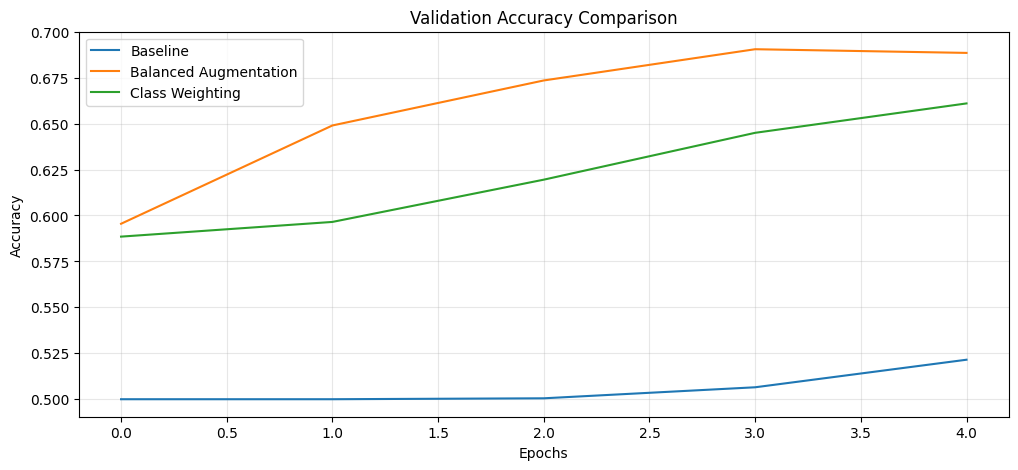

In [18]:
plt.figure(figsize=(12, 5))
for name, history in histories_cifar.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4-7. 모델별 Confusion Matrix 및 Classification Report 비교


Classification Report (Baseline):
              precision    recall  f1-score   support

         Cat     0.8308    0.0540    0.1014      1000
         Dog     0.5111    0.9890    0.6739      1000

    accuracy                         0.5215      2000
   macro avg     0.6709    0.5215    0.3877      2000
weighted avg     0.6709    0.5215    0.3877      2000



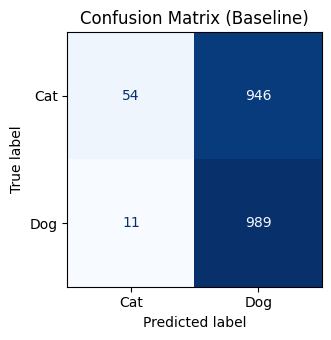

In [19]:
# 1. Baseline 평가
y_pred_base = (model_base.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base, digits=4, target_names=["Cat", "Dog"]))

cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Baseline)")
plt.tight_layout()
plt.show()


Classification Report (Augmentation):
              precision    recall  f1-score   support

         Cat     0.7359    0.5880    0.6537      1000
         Dog     0.6570    0.7890    0.7169      1000

    accuracy                         0.6885      2000
   macro avg     0.6964    0.6885    0.6853      2000
weighted avg     0.6964    0.6885    0.6853      2000



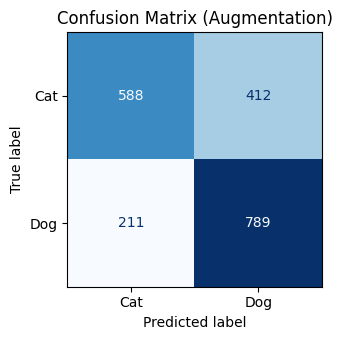

In [20]:
# 2. Balanced Data Augmentation 평가
y_pred_aug = (model_aug.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Augmentation):")
print(classification_report(y_test, y_pred_aug, digits=4, target_names=["Cat", "Dog"]))

cm_aug = confusion_matrix(y_test, y_pred_aug)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Augmentation)")
plt.tight_layout()
plt.show()


Classification Report (Class weighting):
              precision    recall  f1-score   support

         Cat     0.6724    0.6280    0.6494      1000
         Dog     0.6510    0.6940    0.6718      1000

    accuracy                         0.6610      2000
   macro avg     0.6617    0.6610    0.6606      2000
weighted avg     0.6617    0.6610    0.6606      2000



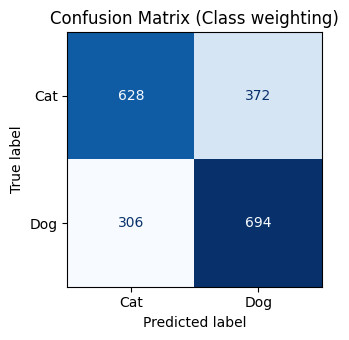

In [21]:
# 3. Class Weighting 평가
y_pred_weighted = (model_weighted.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Class weighting):")
print(classification_report(y_test, y_pred_weighted, digits=4, target_names=["Cat", "Dog"]))

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Class weighting)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 도전과제 종합 정리]
1. ResNet의 Skip Connection은 왜 일반 깊은 망보다 학습 손실을 빠르게 줄이고 깊은 층에서도 안정적으로 수렴하게 할까요?
2. L1, L2 가중치 규제와 Dropout은 각각 가중치를 어떻게 제어하여 과적합을 방지하나요?
3. 불균형 데이터셋에서 Baseline 대비 Class Weighting과 Balanced Data Augmentation을 적용했을 때 소수 클래스(Cat)의 재현율(Recall)과 F1-Score가 어떻게 개선되었나요?


#### ✍️ 답안 — 도전과제 종합 정리

**1. ResNet의 Skip Connection이 학습을 빠르고 안정적으로 만드는 이유**
- 실측(20층 Plain vs Residual Block 10개): Residual Net은 **1 Epoch 만에 Loss 0.26 / Val Acc 0.932**를 기록해, 같은 시점의 Plain(Loss 0.58 / Val Acc 0.887)보다 크게 앞섰다. Val Accuracy 0.96대 도달도 Residual은 **2 Epoch**, Plain은 **약 5 Epoch**가 걸렸다. 30 Epoch 후에는 둘 다 Loss ≈0.08 / Val Acc ≈0.96으로 수렴했다.
- 원리: Residual Block의 출력은 $H(x) = \mathrm{ReLU}(F(x) + x)$ 이므로, 역전파 시 기울기가
  $$\frac{\partial H}{\partial x} = \frac{\partial F}{\partial x} + 1$$
  형태가 된다. **항상 더해지는 +1 경로(항등 지름길)** 때문에 $\partial F/\partial x$가 0에 가까워져도 기울기가 소멸하지 않고 초기 층까지 그대로 흘러간다. Lab 4-3에서 본 "곱셈 누적에 의한 지수적 감쇠"가 **덧셈 구조로 우회**되는 것이다.
- 또한 각 블록은 전체 사상 $H(x)$가 아니라 **잔차 $F(x) = H(x) - x$ 만 학습**하면 된다. 항등 사상이 최적일 때 가중치를 0으로 보내면 되므로, 층을 더 쌓아도 성능이 나빠지는 **Degradation 문제**가 완화된다.
- 정직한 해석: 이번 실험의 20층은 ReLU를 쓰기 때문에 Plain도 결국 수렴했다. Residual의 이점은 **초기 수렴 속도와 곡선의 안정성**으로 나타났고, 층이 50·100층으로 깊어지거나 포화형 활성화를 쓸 때 비로소 결정적 차이가 된다.

**2. L1 / L2 규제와 Dropout이 과적합을 막는 방식 (실측 비교)**

| 기법 | Val Loss 최종 (200 Epoch) | 거동 |
|:---|:---:|:---|
| 규제 없음 | **≈ 1.44 (발산)** | 7 Epoch에서 최저 0.32 → 이후 계속 상승 |
| L1 (0.001) | **≈ 0.44 (안정)** | 50 Epoch 이후 평탄하게 수렴 |
| L2 (0.001) | ≈ 0.59 (완만한 상승) | 발산은 억제 |
| L1 + L2 (0.001) | **≈ 0.44 (안정)** | 가장 평탄, Val Acc 0.833 유지 |
| Dropout(0.5) 미적용 | ≈ 1.41 (발산) | Val Acc 0.867 → **0.767 하락** |
| **Dropout(0.5) 적용** | **≈ 0.40 ~ 0.56 (안정)** | Val Acc **0.833 유지** |

- **L2 (Ridge, Weight Decay)**: 손실에 $\lambda \sum w^2$ 를 더한다. 기울기에 $2\lambda w$ 가 추가되어 갱신마다 가중치가 **0쪽으로 비례 축소**된다. 가중치 크기를 전반적으로 작게 눌러 결정 경계를 매끄럽게 만들지만, 정확히 0으로 만들지는 않는다.
- **L1 (Lasso)**: $\lambda \sum |w|$ 를 더한다. 기울기가 $\lambda \cdot \mathrm{sign}(w)$ 로 **크기와 무관한 상수**이므로, 작은 가중치는 실제로 **0이 되어 연결이 끊긴다(Sparsity)**. 결과적으로 자동 특징 선택 효과가 있어 불필요한 센서/특징이 많은 제조 데이터에서 유용하다.
- **L1 + L2 (ElasticNet)**: 두 효과를 결합 — 희소성 + 매끄러운 축소. 이번 실험에서 가장 안정적인 Val Loss를 보였다.
- **Dropout**: 가중치를 직접 제약하는 것이 아니라, 매 배치마다 뉴런 50%를 무작위로 끈다. 특정 뉴런 조합에만 의존하는 **공적응(Co-adaptation)을 차단**하고, 사실상 지수적으로 많은 얇은 서브네트워크의 **앙상블 평균**을 학습하는 효과를 낸다. 추론 시에는 전체 뉴런을 사용한다.
- 요약: **L1/L2는 가중치의 크기를 제약(파라미터 공간 축소), Dropout은 네트워크 구조를 무작위화(앙상블 효과)** — 접근은 다르지만 목적은 같고, 실무에서는 함께 쓰는 경우가 많다.

**3. 불균형 데이터에서 Class Weighting / Balanced Augmentation의 개선 효과 (CIFAR-10 Cat vs Dog, 실측)**

학습셋 불균형: **Cat 1,000 : Dog 5,000 (1:5)** / 테스트셋은 균형 1,000:1,000
계산된 클래스 가중치: **{Cat: 3.0, Dog: 0.6}** / 증강 후 학습셋: **5,000 : 5,000**

| 기법 | Accuracy | **Cat(소수) Recall** | Cat F1 | Macro F1 |
|:---|:---:|:---:|:---:|:---:|
| Baseline | 0.5215 | **0.0540** | 0.1014 | 0.3877 |
| **Balanced Augmentation** | **0.6885** | 0.5880 | **0.6537** | **0.6853** |
| **Class Weighting** | 0.6610 | **0.6280** | 0.6494 | 0.6606 |

- **Baseline은 사실상 붕괴 상태다.** Cat Recall이 **5.4%** — 1,000마리 고양이 중 946마리를 개로 오판했다. 반대로 Dog Recall은 98.9%다. 즉 모델은 "거의 전부 Dog라고 답하는" 전략을 학습했고, 이것이 불균형 학습셋에서는 손실을 최소화하는 합리적 선택이었다.
- **Balanced Augmentation**: Cat Recall 0.054 → **0.588 (약 10.9배)**, Cat F1 0.1014 → **0.6537 (약 6.4배)**, Accuracy 0.52 → **0.69**. 소수 클래스를 회전·이동·반전으로 늘려 **데이터 수준**에서 비율을 맞춘 결과다.
- **Class Weighting**: Cat Recall 0.054 → **0.628**로 세 기법 중 소수 클래스 검출력이 가장 높다. 손실 함수에서 Cat 오류에 5배(3.0 / 0.6) 페널티를 주어 **손실 수준**에서 비대칭을 교정했다. 다만 Cat을 적극적으로 잡으려다 Cat Precision이 0.672로 낮아져 전체 Accuracy·F1은 Augmentation보다 약간 낮다.
- **선택 기준**: 불량 미검출(FN) 비용이 절대적으로 큰 공정이면 **Recall이 가장 높은 Class Weighting**, 전체 균형(F1·Accuracy)이 중요하면 **Balanced Augmentation**. 구현 비용 면에서 `class_weight`는 한 줄로 끝나므로 먼저 시도할 가치가 있고, 두 기법을 함께 적용할 수도 있다.
- Lab 4-3의 교훈과 연결: Baseline의 Accuracy 0.52는 **균형 테스트셋에서 측정했기 때문에** 정직하게 낮게 나왔다. 만약 학습셋과 같은 1:5 불균형 테스트셋으로 평가했다면 약 83%가 나와 "쓸 만한 모델"로 착각했을 것이다. **평가셋 설계가 지표 신뢰도를 결정한다.**

> 📌 실행 참고: Part 1의 `residual_block_*/Relu` 관련 `No registered OpKernel` 경고는 커스텀 Layer를 쓸 때 TensorFlow 그래프 최적화기가 출력하는 정보성 메시지로, 학습·평가 결과에는 영향이 없다(Loss/Accuracy 곡선 정상 산출 확인).